In [1]:
import os
import pandas as pd
from obspy import read
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.fft import fft
from scipy.stats import entropy

In [2]:
splits_root = r"E:\Skripsi\DEC\dataset\ae-supervised-dataset\splits-baru-XGB"
train_manifest = os.path.join(splits_root, "train_scaled.csv")
val_manifest  = os.path.join(splits_root, "val_scaled.csv")
test_manifest  = os.path.join(splits_root, "test_scaled.csv")

In [3]:
def load_features(csv_path):
    df = pd.read_csv(csv_path)
    X = df.drop(columns=['path', 'label']).values  # Semua kolom selain 'path' dan 'label' adalah fitur
    y = df['label'].values                         
    return X, y

In [4]:

X_train, y_train = load_features(train_manifest)
X_val, y_val = load_features(val_manifest)
X_test, y_test = load_features(test_manifest)

print("Train full shape:", X_train.shape)
print("Train shape:", X_train.shape)
print("val shape:", X_val.shape)
print("Test shape :", X_test.shape)

Train full shape: (1796, 10)
Train shape: (1796, 10)
val shape: (450, 10)
Test shape : (562, 10)


In [5]:
def class_distribution(labels, name):
    unique, counts = np.unique(labels, return_counts=True)
    dist = pd.DataFrame({
        "class": unique,
        "count": counts,
        "percentage": (counts / counts.sum() * 100).round(2)
    })
    print(f"\n{name} distribution:")
    print(dist.to_string(index=False))

class_distribution(y_train, "Train")
class_distribution(y_val, "Validation")
class_distribution(y_test, "Test")


Train distribution:
   class  count  percentage
      MP    915       50.95
ROCKFALL    800       44.54
     VTB     81        4.51

Validation distribution:
   class  count  percentage
      MP    229       50.89
ROCKFALL    201       44.67
     VTB     20        4.44

Test distribution:
   class  count  percentage
      MP    286       50.89
ROCKFALL    251       44.66
     VTB     25        4.45


In [6]:
le = LabelEncoder()

le.fit(y_train)

y_train = le.transform(y_train)
y_val   = le.transform(y_val)
y_test  = le.transform(y_test)

In [7]:
from xgboost import XGBClassifier

clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
)

eval_set = [(X_train, y_train), (X_val, y_val)]
clf.fit(
    X_train, y_train,
    eval_set=eval_set,
)

clf.save_model("Baseline_XGboost.json")


[0]	validation_0-mlogloss:0.98578	validation_1-mlogloss:0.98752
[1]	validation_0-mlogloss:0.89116	validation_1-mlogloss:0.89535
[2]	validation_0-mlogloss:0.80995	validation_1-mlogloss:0.81519
[3]	validation_0-mlogloss:0.74083	validation_1-mlogloss:0.74765
[4]	validation_0-mlogloss:0.68012	validation_1-mlogloss:0.68902
[5]	validation_0-mlogloss:0.62823	validation_1-mlogloss:0.63797
[6]	validation_0-mlogloss:0.58210	validation_1-mlogloss:0.59244
[7]	validation_0-mlogloss:0.54054	validation_1-mlogloss:0.55243
[8]	validation_0-mlogloss:0.50351	validation_1-mlogloss:0.51720
[9]	validation_0-mlogloss:0.47178	validation_1-mlogloss:0.48788
[10]	validation_0-mlogloss:0.44205	validation_1-mlogloss:0.46183
[11]	validation_0-mlogloss:0.41617	validation_1-mlogloss:0.43784
[12]	validation_0-mlogloss:0.39251	validation_1-mlogloss:0.41507
[13]	validation_0-mlogloss:0.37115	validation_1-mlogloss:0.39467
[14]	validation_0-mlogloss:0.35227	validation_1-mlogloss:0.37809
[15]	validation_0-mlogloss:0.33493	

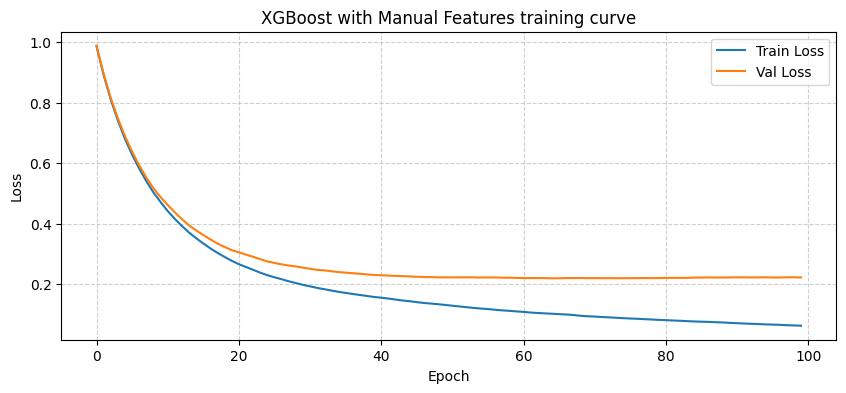

In [8]:
results = clf.evals_result()
train_loss = results['validation_0']['mlogloss']
val_loss = results['validation_1']['mlogloss']
plt.figure(figsize=(10,4))
plt.grid(True, linestyle='--', alpha=0.6)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('XGBoost with Manual Features training curve')
plt.legend()
plt.show()


Accuracy: 0.9004

              precision    recall  f1-score   support

           0     0.8859    0.9231    0.9041       286
           1     0.9167    0.8765    0.8961       251
           2     0.9167    0.8800    0.8980        25

    accuracy                         0.9004       562
   macro avg     0.9064    0.8932    0.8994       562
weighted avg     0.9010    0.9004    0.9003       562



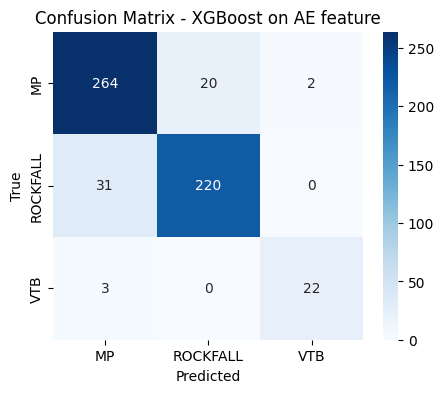

In [9]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score, accuracy_score
import matplotlib.pyplot as plt

# Prediksi label
y_pred = clf.predict(X_test)

# Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

# Classification Report
print(classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - XGBoost on AE feature")
plt.show()

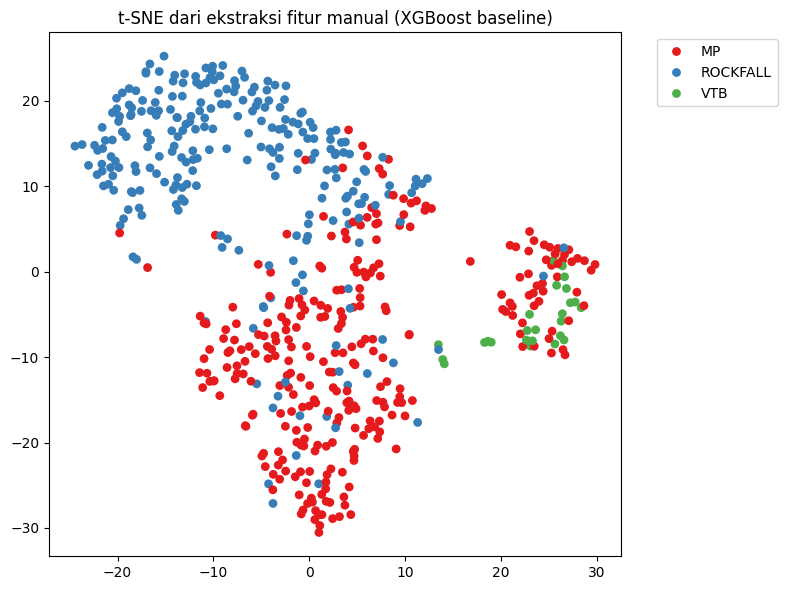

Total misclassified: 56
Example indices: [ 25  59  81  84  86  88 103 107 111 120]
Index 25 -> True: ROCKFALL, Pred: MP
Index 59 -> True: ROCKFALL, Pred: MP
Index 81 -> True: ROCKFALL, Pred: MP
Index 84 -> True: ROCKFALL, Pred: MP
Index 86 -> True: ROCKFALL, Pred: MP
Index 88 -> True: VTB, Pred: MP
Index 103 -> True: MP, Pred: VTB
Index 107 -> True: ROCKFALL, Pred: MP
Index 111 -> True: ROCKFALL, Pred: MP
Index 120 -> True: MP, Pred: VTB


In [10]:
from sklearn.manifold import TSNE
# 1. t-SNE projection of latent space
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate='auto')
emb_2d = tsne.fit_transform(X_test)

# 2. Predictions from your classifier (XGBoost)
y_pred = clf.predict(X_test)   # not model.predict()
mask_bad = (y_pred != y_test)

# 3. Plot clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=emb_2d[:,0], y=emb_2d[:,1],
    hue=le.inverse_transform(y_test),
    palette='Set1', s=40, alpha=1, edgecolor='none'
)

plt.title("t-SNE dari ekstraksi fitur manual (XGBoost baseline)")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

# 5. Print which points were wrong
bad_indices = np.where(mask_bad)[0]
print("Total misclassified:", len(bad_indices))
print("Example indices:", bad_indices[:10])

for i in bad_indices[:10]:
    print(f"Index {i} -> True: {le.inverse_transform([y_test[i]])[0]}, "
          f"Pred: {le.inverse_transform([y_pred[i]])[0]}")

# 4. Overlay misclassified points
# plt.scatter(
#     emb_2d[mask_bad,0], emb_2d[mask_bad,1],
#     c='black', s=15, label='Misclassified', alpha=0.8
# )